# Multiple Testing & False Discovery Rate

When we run many hypothesis tests simultaneously, the chance of at least one false positive explodes — even if every null hypothesis is true.

For $m$ independent tests each at $\alpha=0.05$, the **family-wise error rate** (FWER) is:
$$\text{FWER} = 1 - (1-\alpha)^m$$

At $m=20$ tests: FWER $= 1-(0.95)^{20} \approx 64\%$

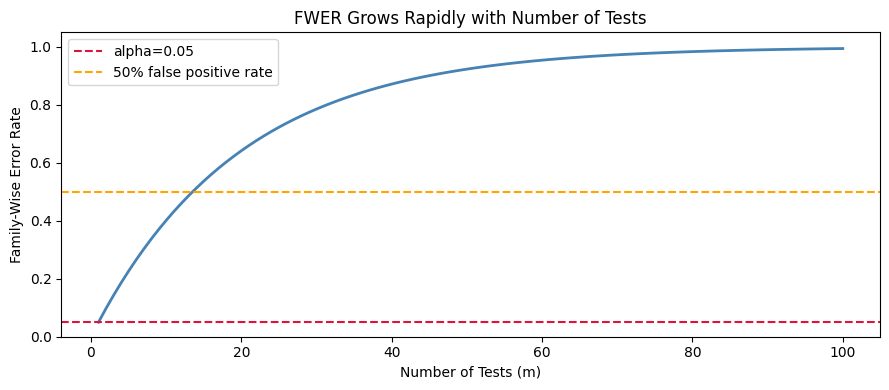

m=  1 tests → FWER = 0.0500
m=  5 tests → FWER = 0.2262
m= 10 tests → FWER = 0.4013
m= 20 tests → FWER = 0.6415
m= 50 tests → FWER = 0.9231
m=100 tests → FWER = 0.9941


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Show FWER growth
alpha = 0.05
m_vals = np.arange(1, 101)
fwer   = 1 - (1 - alpha)**m_vals

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(m_vals, fwer, 'steelblue', lw=2)
ax.axhline(0.05, color='crimson', ls='--', lw=1.5, label='alpha=0.05')
ax.axhline(0.50, color='orange',  ls='--', lw=1.5, label='50% false positive rate')
ax.set_xlabel('Number of Tests (m)')
ax.set_ylabel('Family-Wise Error Rate')
ax.set_title('FWER Grows Rapidly with Number of Tests')
ax.legend()
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

for m in [1, 5, 10, 20, 50, 100]:
    print(f'm={m:>3} tests → FWER = {1-(1-alpha)**m:.4f}')


## Corrections

### 1. Bonferroni Correction
Most conservative: divide $\alpha$ by $m$.
$$\alpha_{Bonferroni} = \frac{\alpha}{m}$$
Controls FWER but reduces power (many true effects missed).

### 2. Benjamini-Hochberg (BH) Procedure
Controls the **False Discovery Rate** (FDR = expected proportion of false positives among rejected tests) rather than FWER. Much more powerful for large-scale testing.

**BH procedure:**
1. Sort p-values: $p_{(1)} \leq p_{(2)} \leq \ldots \leq p_{(m)}$
2. Find the largest $k$ where $p_{(k)} \leq \frac{k}{m} \cdot \alpha$
3. Reject $H_0$ for all $i \leq k$

In [2]:
from statsmodels.stats.multitest import multipletests

rng = np.random.default_rng(seed=42)

# Simulate 100 tests: 80 true nulls, 20 true effects
m_total  = 100
m_null   = 80
m_effect = 20

# p-values from null tests (uniform) and true-effect tests (small p-values)
p_null   = rng.uniform(0, 1, size=m_null)             # H0 true: uniform
p_effect = rng.beta(0.5, 5, size=m_effect)            # H0 false: skewed toward 0
p_vals   = np.concatenate([p_null, p_effect])
true_null = np.array([True]*m_null + [False]*m_effect) # True = null is actually true

# Uncorrected at alpha=0.05
reject_uncorrected = p_vals < 0.05

# Bonferroni
reject_bonf, _, _, _ = multipletests(p_vals, alpha=0.05, method='bonferroni')

# Benjamini-Hochberg
reject_bh,   _, _, _ = multipletests(p_vals, alpha=0.05, method='fdr_bh')

def summarise(name, reject_arr):
    tp = (reject_arr & ~true_null).sum()   # correct rejections
    fp = (reject_arr &  true_null).sum()   # false positives
    fn = (~reject_arr & ~true_null).sum()  # missed effects
    fdr = fp / reject_arr.sum() if reject_arr.sum() > 0 else 0
    print(f'{name:<20}: Rejected={reject_arr.sum():>3} | TP={tp:>2} FP={fp:>2} FN={fn:>2} | FDR={fdr:.2f}')

print(f'True nulls: {m_null}, True effects: {m_effect}')
print()
summarise('Uncorrected',    reject_uncorrected)
summarise('Bonferroni',     reject_bonf)
summarise('Benjamini-Hochberg', reject_bh)


True nulls: 80, True effects: 20

Uncorrected         : Rejected= 14 | TP=11 FP= 3 FN= 9 | FDR=0.21
Bonferroni          : Rejected=  3 | TP= 3 FP= 0 FN=17 | FDR=0.00
Benjamini-Hochberg  : Rejected=  3 | TP= 3 FP= 0 FN=17 | FDR=0.00


## Simulation: False Discovery Rate at Scale

In [3]:
n_sims = 1000
fdr_uncorr = []
fdr_bonf   = []
fdr_bh_sim = []

for _ in range(n_sims):
    p_n = rng.uniform(0, 1, size=m_null)
    p_e = rng.beta(0.5, 5, size=m_effect)
    pv  = np.concatenate([p_n, p_e])
    tn  = np.array([True]*m_null + [False]*m_effect)

    for fdr_list, method in [
        (fdr_uncorr, None),
        (fdr_bonf,   'bonferroni'),
        (fdr_bh_sim, 'fdr_bh')
    ]:
        if method is None:
            rej = pv < 0.05
        else:
            rej, _, _, _ = multipletests(pv, alpha=0.05, method=method)
        fp = (rej & tn).sum()
        fdr_list.append(fp / rej.sum() if rej.sum() > 0 else 0)

print('Mean FDR over 1,000 simulations:')
print(f'  Uncorrected        : {np.mean(fdr_uncorr):.3f}')
print(f'  Bonferroni         : {np.mean(fdr_bonf):.3f}')
print(f'  Benjamini-Hochberg : {np.mean(fdr_bh_sim):.3f}')
print()
print('BH controls FDR near 0.05 while rejecting more true effects than Bonferroni.')


Mean FDR over 1,000 simulations:
  Uncorrected        : 0.274
  Bonferroni         : 0.021
  Benjamini-Hochberg : 0.039

BH controls FDR near 0.05 while rejecting more true effects than Bonferroni.


---
## ML/AI Connection

- **Feature selection with many features:** testing 1,000 features for association with the target at $\alpha=0.05$ expects 50 false discoveries — always apply Benjamini-Hochberg.
- **NAS (Neural Architecture Search) and ablation studies** test many architectural choices — multiple testing corrections prevent spurious conclusions.
- **Online A/B testing:** running concurrent experiments on overlapping user populations creates a multiple comparisons problem.
